# Clustering K-Prototypes — perfis de pacientes

Agrupamento misto (categórico + numérico) de pacientes TCR/UTI.

In [1]:
from pathlib import Path

import pandas as pd

from tcr_community.multivariate.kprototypes import (
    cluster_profile_table,
    cluster_vs_outcome_table,
    cost_by_k,
    fit_kprototypes,
)
from tcr_community.multivariate.prep import prepare_clustering_frame
from tcr_community.pipeline.prepare_data import PROCESSED_PATH, prepare_data

if not Path(PROCESSED_PATH).exists():
    prepare_data()

df = pd.read_parquet(PROCESSED_PATH)
frame = prepare_clustering_frame(df)
frame.data.shape

(205, 13)

## Escolha de k (curva de custo/cotovelo)

In [2]:
costs = cost_by_k(frame, list(range(2, 8)))
costs

,k,cost
0,2,33939.593024
1,3,24514.097717
2,4,17402.263890
3,5,15154.031055
4,6,13513.922902
5,7,12183.780280


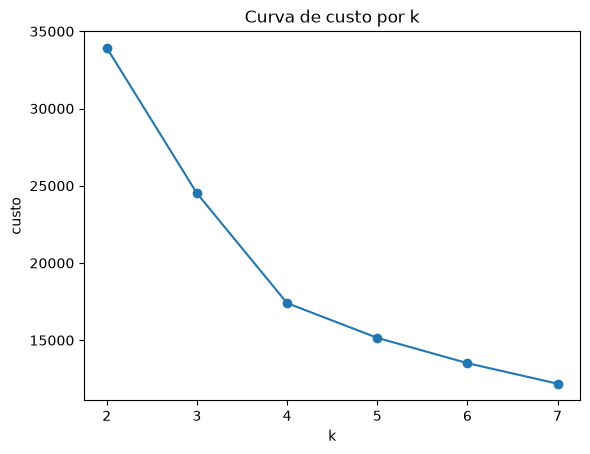

In [3]:
import matplotlib.pyplot as plt

plt.plot(costs["k"], costs["cost"], marker="o")
plt.xlabel("k")
plt.ylabel("custo")
plt.title("Curva de custo por k")
plt.show()

## Ajuste final (k=4) e perfis

In [4]:
result = fit_kprototypes(frame, k=4)
profile = cluster_profile_table(frame, result.labels)
profile

,n,comorbidades,ventilacao_mecanica,drogas_vasoativas,transfusao_sanguinea,hemodialise,procedimento_cirurgico,cuidados_paliativos,diagnostico_principal,genero,faixa_etaria,local_residencia,escala_apache_ii,tempo_internacao_uti
cluster,,,,,,,,,,,,,,
0,10,SIM,SIM,SIM,SIM,NAO,SIM,NAO,ACIDENTE_VASCULAR_CEREBRAL_ISQUEMICO,M,32,SIM,32.600000,55.200000
1,77,SIM,SIM,SIM,NAO,NAO,NAO,NAO,SEPTICEMIA,F,80,SIM,35.519481,5.597403
2,48,SIM,SIM,SIM,NAO,NAO,NAO,SIM,PNEUMONIA_NE,M,76,SIM,28.375000,23.937500
3,70,SIM,SIM,SIM,NAO,NAO,NAO,NAO,DPOC_EXACERBADO,M,83,SIM,19.528571,6.100000


In [5]:
from tcr_community.schemas.columns import COL_DESFECHO_PADRONIZADO

cluster_vs_outcome_table(df, frame, result.labels, target=COL_DESFECHO_PADRONIZADO)

,ALTA,DESCONHECIDO,OBITO,OUTRO,TRANSFERENCIA,pct_ALTA,pct_DESCONHECIDO,pct_OBITO,pct_OUTRO,pct_TRANSFERENCIA
cluster,,,,,,,,,,
0,1,0,9,0,0,0.100000,0.000000,0.900000,0.000000,0.000000
1,1,0,73,1,2,0.012987,0.000000,0.948052,0.012987,0.025974
2,1,0,45,0,2,0.020833,0.000000,0.937500,0.000000,0.041667
3,18,1,39,1,11,0.257143,0.014286,0.557143,0.014286,0.157143
